# 1. Imports

In [25]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.metrics import accuracy_score, recall_score, brier_score_loss, precision_score
from collections import Counter

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', None)

# 2. Load & Condition Data

In [ ]:
from pathlib import Path
import os
import sys

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)

EVALUATION_ARTIFACTS_DIR = REPO_ROOT / "artifacts" / "evaluation"
EVALUATION_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Public/user-facing default: read the runtime database generated by enrich_dataset.py.
# Private archived DB snapshots, if any, should live under project_history/ and are not required.
DB_PATH = Path(os.getenv("COMPLIANCE_AUDIT_DB", REPO_ROOT / "compliance_audit.db"))

print("Working directory:", Path.cwd())
print("Evaluation source database:", DB_PATH)
print("Database exists:", DB_PATH.exists())

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}. "
        "Run `python enrich_dataset.py` first, or set COMPLIANCE_AUDIT_DB "
        "to a local archived DB path."
    )

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM audited_trades", conn)

print(df.shape)
display(df.head())

# Ensure comparability of predicted and expected workflow routing buckets / escalation states
df["predicted_workflow_bucket"] = df["escalation_level"].map(lambda s: "Auto_pass" if s == "none" else s)
df["predicted_workflow_bucket"] = df["predicted_workflow_bucket"].apply(lambda s: s.upper())
df["expected_workflow_bucket"] = df["expected_workflow_bucket"].apply(lambda s: s.upper())

# Ensure lists stored as strings are converted to actual lists for analysis
LIST_COLUMNS = ["relevant_policies", "retrieved_policies"]
for col in LIST_COLUMNS:
    df[col] = df[col].apply(ast.literal_eval)

Working directory: c:\Users\jason\Projects\ai-compliance-copilot
Database: c:\Users\jason\Projects\ai-compliance-copilot\compliance_audit.db
Database exists: True
(780, 33)


,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,advisor_id,advisor_experience,advisor_history_risk,advisor_rationale,advisor_notes,kyc_completeness,true_compliance,case_type,scenario_name,difficulty,severity_tier,expected_workflow_bucket,relevant_policies,primary_policy,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,flag_reasons,retrieved_policies,retrieved_chunks
0,TRADE-0cd559e5,2026-06-09 16:55:41.204422,36,222771.0,High,Advanced,Growth,Long,T-Bills,23192.64,ADV-006,Senior,Low,Trade implemented to support strategic portfolio positioning while maintaining consistency with client risk parameters.,Client remains comfortable with current strategy and long-term investment approach.,Complete,1,Aligned Recommendation,Conflicting Signals,Easy,Low,Auto_pass,"[""POL-010-CLIENT-OBJECTIVE""]",POL-010-CLIENT-OBJECTIVE,1.0,1,5.0,0.690,queue,5.0,"The client has a high risk tolerance and a growth objective, yet the advisor recommended T-Bills, which are conservative instruments. While the recommendation is not a violation, the advisor's rat...","[""POL-010-CLIENT-OBJECTIVE"", ""POL-005-SENIOR-VULNERABLE-CLIENTS"", ""POL-002-KYC"", ""POL-004-CONCENTRATION"", ""POL-006-HIGH-RISK-PRODUCTS""]","[{""chunk_id"": ""POL-010-CLIENT-OBJECTIVE_CH_002"", ""policy_id"": ""POL-010-CLIENT-OBJECTIVE"", ""section_scope"": ""2. General Principles"", ""text"": ""[POL-010-CLIENT-OBJECTIVE > 2. General Principles]\nInv..."
1,TRADE-d0addf41,2026-06-06 08:59:22.874241,29,102852.0,Medium,Beginner,Growth,Short,Stocks,16508.85,ADV-020,Mid,Low,Trade executed following suitability review confirming consistency with documented objectives and risk tolerance.,Client confirmed financial circumstances remain unchanged since last review.,Complete,1,Risk Signal,Aggressive Horizon,Hard,Medium,Queue,"[""POL-001-SUITABILITY""]",POL-001-SUITABILITY,1.0,1,15.0,0.630,queue,5.0,"The client has a short investment horizon, which is generally inconsistent with a growth-oriented stock investment. The advisor's rationale is generic and fails to address the potential mismatch b...","[""POL-010-CLIENT-OBJECTIVE"", ""POL-002-KYC"", ""POL-004-CONCENTRATION"", ""POL-006-HIGH-RISK-PRODUCTS"", ""POL-005-SENIOR-VULNERABLE-CLIENTS""]","[{""chunk_id"": ""POL-010-CLIENT-OBJECTIVE_CH_002"", ""policy_id"": ""POL-010-CLIENT-OBJECTIVE"", ""section_scope"": ""2. General Principles"", ""text"": ""[POL-010-CLIENT-OBJECTIVE > 2. General Principles]\nInv..."
2,TRADE-14559ae2,2026-06-15 12:51:18.153098,46,169286.0,Medium,Intermediate,Income,Medium,Mutual Funds,84643.00,ADV-005,Mid,Medium,Recommended allocation to Mutual Funds based on current market conditions and client investment objectives.,Trade increases exposure to existing position. Concentration monitored as part of ongoing review.,Uncertain,1,Risk Signal,Risk Signal,Hard,Medium,Queue,"[""POL-001-SUITABILITY"", ""POL-002-KYC"", ""POL-003-SURVEILLANCE"", ""POL-004-CONCENTRATION""]",POL-002-KYC,1.0,1,25.0,0.550,queue,5.0,"The investment amount represents 50% of the client's annual income, which triggers concentration concerns under POL-004-CONCENTRATION. The advisor's rationale is generic and fails to provide speci...","[""POL-010-CLIENT-OBJECTIVE"", ""POL-002-KYC"", ""POL-004-CONCENTRATION"", ""POL-005-SENIOR-VULNERABLE-CLIENTS"", ""POL-001-SUITABILITY""]","[{""chunk_id"": ""POL-010-CLIENT-OBJECTIVE_CH_006"", ""policy_id"": ""POL-010-CLIENT-OBJECTIVE"", ""section_scope"": ""6. Objective Changes"", ""text"": ""[POL-010-CLIENT-OBJECTIVE > 6. Objective Changes]\nChang..."
3,TRADE-4eca99ea,2026-06-29 01:17:38.381031,34,109805.0,High,Beginner,Growth,Long,T-Bills,8357.02,ADV-009,Mid,High,Position established in T-Bills to capitalize on anticipated market opportunities. Client acknowledged increased risk.,Potential profile drift noted and may require follow-up review.,Complete,1,Aligned 

# 3. North Star Metric
### (% cases correctly routed to lowest safe workflow level)

In [27]:
df["correctly_routed"] = (df["predicted_workflow_bucket"] == df["expected_workflow_bucket"])

print(f'Percentage of cases correctly routed to lowest safe workflow level: {df["correctly_routed"].mean()*100:.1f}%')

Percentage of cases correctly routed to lowest safe workflow level: 79.6%


The North Star Metric is lower than compliance classification accuracy because it evaluates the full product workflow, not just whether the AI classified a trade as compliant or non-compliant. This distinction is important because a system can classify compliance correctly while still routing cases to the wrong level of human review.

# 3. Product Success Metrics
## 3.1. Compliance
### 3.1.1 Compliance Classification Accuracy

In [28]:
compliance_accuracy = accuracy_score(df["true_compliance"], df["compliance_label"])

print(f"Compliance classification accuracy: {(compliance_accuracy*100):.1f}%")

Compliance classification accuracy: 99.7%


### 3.1.2. Compliance False Negative Rate

Note: False negatives are non-compliant cases predicted as compliant.

In [29]:
non_compliant_df = df[df["true_compliance"]==0]
compliance_fnr = (non_compliant_df["compliance_label"]!=0).mean()

print(f"Compliance False Negative Rate (%): {(compliance_fnr*100):.1f}%")

Compliance False Negative Rate (%): 0.0%


Out of all non-compliant cases in the evaluation dataset, **none** were misclassified as compliant. This is an important result since missed non-compliant cases are potentially very damaging.

### 3.1.3. Compliance False Positive Rate

Note: False positives are compliant cases predicted as non-compliant.

In [30]:
compliant_df = df[df["true_compliance"]==1]
compliance_fpr = (compliant_df["compliance_label"]==0).mean()

print(f"Compliance False Positive Rate (%): {(compliance_fpr*100):.2f}%")

Compliance False Positive Rate (%): 0.38%


In [31]:
compliance_false_positive_count = ((df["true_compliance"] == 1) & (df["compliance_label"] == 0)).sum()

print(f"Compliance False Positive Count: {compliance_false_positive_count}")

Compliance False Positive Count: 2


Out of all compliant cases in the dataset, **two** were misclassified as non-compliant. False positives aren't critical classification failures like false negatives are in this application scenario, but they reduce the efficiency gains achieved with the automated system. 0.38% is still a very low false positive rate though; the two false positive cases are shown below:

In [32]:
df[(df["true_compliance"]==1) & (df["compliance_label"]==0)]

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,advisor_id,advisor_experience,advisor_history_risk,advisor_rationale,advisor_notes,kyc_completeness,true_compliance,case_type,scenario_name,difficulty,severity_tier,expected_workflow_bucket,relevant_policies,primary_policy,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,flag_reasons,retrieved_policies,retrieved_chunks,predicted_workflow_bucket,correctly_routed
673,TRADE-7f3b047b,2026-06-19 18:12:20.281759,30,115744.0,High,Beginner,Preservation,Medium,Stocks,14022.3,ADV-013,Junior,Low,"Reviewed risks, fees, and expected performance characteristics of Stocks. Client demonstrated understanding prior to execution.",Client confirmed understanding of investment objectives and associated risks.,Complete,1,Risk Signal,Aggressive Objective,Hard,Medium,QUEUE,"[POL-001-SUITABILITY, POL-010-CLIENT-OBJECTIVE]",POL-001-SUITABILITY,0.4,0,50.0,0.855,priority,89.35,"The client has a stated investment objective of capital preservation, which is fundamentally inconsistent with the purchase of stocks. Although the client has a high risk tolerance, the advisor's ...","[POL-002-KYC, POL-010-CLIENT-OBJECTIVE, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-004-CONCENTRATION, POL-006-HIGH-RISK-PRODUCTS]","[{""chunk_id"": ""POL-002-KYC_CH_005"", ""policy_id"": ""POL-002-KYC"", ""section_scope"": ""5. Investment Knowledge Classification"", ""text"": ""[POL-002-KYC > 5. Investment Knowledge Classification]\nInvestme...",PRIORITY,False
687,TRADE-1131f092,2026-06-03 10:38:54.991103,39,119164.0,Low,Intermediate,Income,Long,Mutual Funds,59582.0,ADV-007,Mid,Medium,Trade completed in Mutual Funds to pursue potential growth opportunities while monitoring overall portfolio risk.,Market volatility discussed during suitability review.,Uncertain,1,Risk Signal,Risk Signal,Hard,Medium,QUEUE,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SURVEILLANCE, POL-004-CONCENTRATION]",POL-002-KYC,0.4,0,65.0,0.775,priority,102.25,"The client has a Low risk tolerance, yet the advisor recommended a growth-oriented investment, which is inconsistent with the client's profile per POL-001-SUITABILITY. Furthermore, the investment ...","[POL-010-CLIENT-OBJECTIVE, POL-002-KYC, POL-004-CONCENTRATION, POL-005-SENIOR-VULNERABLE-CLIENTS, POL-001-SUITABILITY]","[{""chunk_id"": ""POL-010-CLIENT-OBJECTIVE_CH_006"", ""policy_id"": ""POL-010-CLIENT-OBJECTIVE"", ""section_scope"": ""6. Objective Changes"", ""text"": ""[POL-010-CLIENT-OBJECTIVE > 6. Objective Changes]\nChang...",PRIORITY,False


## 3.2. Workflow Routing

### 3.2.1. Workflow Routing Contingency Table

In [33]:
workflow_table = pd.crosstab(df["expected_workflow_bucket"], df["predicted_workflow_bucket"], margins=True)

workflow_table

predicted_workflow_bucket,AUTO_PASS,PRIORITY,QUEUE,URGENT,All
expected_workflow_bucket,,,,,
AUTO_PASS,181,7,84,0,272
PRIORITY,0,195,0,16,211
QUEUE,4,17,228,0,249
URGENT,0,31,0,17,48
All,185,250,312,33,780


In my case workflow design, trades are routed to 1 of 4 categories -- from highest to lowest review priority: "urgent", "priority", "queue", and "auto-pass" ("auto-pass" is the only category treated as not requiring human review). We see in the contingency table the following cases:
- 31 "urgent" cases under-escalated as "priority" cases
- 4 "queue" cases under-escalated as "auto-pass" cases

Most workflow errors were adjacent-category errors rather than extreme routing failures. The largest safety-relevant weakness was urgent cases being routed as priority, while the largest efficiency weakness was auto-pass cases being unnecessarily routed to human review.

### 3.2.2. Workflow Routing Accuracy

In [34]:
workflow_accuracy = (
    df["expected_workflow_bucket"]
    ==
    df["predicted_workflow_bucket"]
).mean()

print(f"Workflow Accuracy: {(workflow_accuracy*100):.1f}%")

Workflow Accuracy: 79.6%


### 3.2.3. "Urgent" Case Recall

In [35]:
urgent_df = df[df["expected_workflow_bucket"]=="URGENT"]
urgent_recall = recall_score(urgent_df["expected_workflow_bucket"], urgent_df["predicted_workflow_bucket"], pos_label="URGENT")

print(f"Urgent Case Recall: {(urgent_recall*100):.1f}%")

Urgent Case Recall: 35.4%


Thirty-one of 48 urgent cases are under-escalated as "priority" cases (as seen in the contingency table) and therefore still destined for human review, but not with the greatest urgency. This suggests the system is usually recognizing that these cases require human review, but is not reliably distinguishing between “priority” and “urgent” levels of review.

### 3.2.4. Unsafe Auto-pass Rate

In [36]:
autopass_pred_df = df[df["predicted_workflow_bucket"]=="AUTO_PASS"]
unsafe_autopass_rate = (autopass_pred_df["expected_workflow_bucket"]!="AUTO_PASS").mean()

print(f"Unsafe Auto-pass Rate (%): {(unsafe_autopass_rate*100):.1f}%")

Unsafe Auto-pass Rate (%): 2.2%


Four of 185 cases routed as "auto-pass" (i.e. not requiring human review) should have been routed as "queue" cases (as seen in the contingency table), destined for human review, albeit with lower priority.

### 3.2.5. Auto-pass Over-escalation

In [37]:
autopass_expect_df = df[df["expected_workflow_bucket"]=="AUTO_PASS"]
ap_overescalated = (autopass_expect_df["predicted_workflow_bucket"] != "AUTO_PASS").mean()

print(f"Auto-pass over-escalation: {(ap_overescalated*100):.1f}%")

Auto-pass over-escalation: 33.5%


Ninety-one of 272 auto-pass cases were over-escalated as "queue" or "priority" cases, reducing workflow efficiency gains achieved with the automation system.

### 3.2.6. Escalation (to human review) Precision

In [38]:
predicted_escalated = df["predicted_workflow_bucket"] != "AUTO_PASS"
expected_escalated = df["expected_workflow_bucket"] != "AUTO_PASS"

escalation_precision = (predicted_escalated & expected_escalated).sum() / predicted_escalated.sum()

print(f"'Human-review needed' prediction precision: {(escalation_precision*100):.1f}%")

'Human-review needed' prediction precision: 84.7%


The majority of cases requiring some level of human review were routed by the system with the correct amount of urgency, although there's room for future improvement.

Nonetheless, with the following current observations:
- no compliance false negatives
- a very low rate of compliance false positives
- workflow/escalation under- and over-escalated cases generally being placed in adjacent categories

taken together, the results suggest that the current implementation may have value as a human compliance-review decision-support system, but not as an autonomous compliance adjudication system.

## 3.3. Simulated Reviewer Trust Proxy

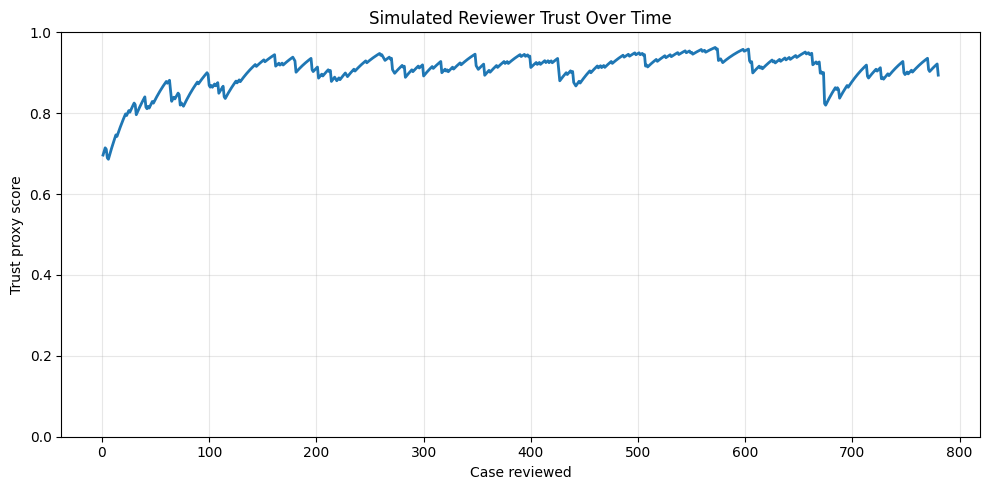

Saved: c:\Users\jason\Projects\ai-compliance-copilot\artifacts\evaluation\trust_proxy_over_time.png
Initial trust proxy: 0.700
Final trust proxy: 0.894
Minimum trust proxy: 0.686
Maximum trust proxy: 0.963
Mean trust proxy: 0.904
Net trust change: +0.194


In [39]:
trust = 0.7
trust_history = []

ROUTE_ORDER = {
    "AUTO_PASS": 0,
    "NONE": 0,
    "QUEUE": 1,
    "PRIORITY": 2,
    "URGENT": 3,
}

def classify_routing(row):
    expected = ROUTE_ORDER[row.expected_workflow_bucket]
    predicted = ROUTE_ORDER[row.predicted_workflow_bucket]

    if predicted == expected:
        return "routing_correct"
    elif predicted > expected:
        return "over_escalated"
    else:
        return "under_escalated"
    
def trust_delta(row):
    assessment_correct = (
        row.compliance_label == row.true_compliance
    )

    routing_outcome = classify_routing(row)

    if assessment_correct:
        assessment_outcome = "assessment_correct"
    else:
        assessment_outcome = "assessment_incorrect"

    trust_delta_map = {
        ("assessment_correct", "routing_correct"): 0.030,
        ("assessment_correct", "over_escalated"): -0.005,
        ("assessment_correct", "under_escalated"): -0.030,

        ("assessment_incorrect", "routing_correct"): -0.005,
        ("assessment_incorrect", "over_escalated"): -0.025,
        ("assessment_incorrect", "under_escalated"): -0.070,
    }

    delta = trust_delta_map[(assessment_outcome, routing_outcome)]

    if not assessment_correct and row.confidence_score >= 0.8:
        delta -= 0.060

    if assessment_correct and row.confidence_score <= 0.4:
        delta -= 0.015

    return delta

# Generate trust proxy data
for row in df.itertuples():
    delta = trust_delta(row)
    if delta >= 0:
        trust = trust + delta * (1 - trust)
    else:
        trust = trust + delta * trust
    trust = max(0, min(1.0, trust))
    trust_history.append(trust)

df["trust_proxy"] = trust_history

# Plot trust proxy data
# Make an explicit x-axis so the chart is easy to explain.
df = df.reset_index(drop=True)
df["interaction_number"] = df.index + 1

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df["interaction_number"], df["trust_proxy"], linewidth=2)

ax.set_title("Simulated Reviewer Trust Over Time")
ax.set_xlabel("Case reviewed")
ax.set_ylabel("Trust proxy score")
ax.set_ylim(0, 1)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save plot to a PNG file
TRUST_PROXY_PATH = EVALUATION_ARTIFACTS_DIR / "trust_proxy_over_time.png"
fig.savefig(TRUST_PROXY_PATH, dpi=200, bbox_inches="tight")
print("Saved:", TRUST_PROXY_PATH)

print(f"Initial trust proxy: {0.7:.3f}")
print(f"Final trust proxy: {df['trust_proxy'].iloc[-1]:.3f}")
print(f"Minimum trust proxy: {df['trust_proxy'].min():.3f}")
print(f"Maximum trust proxy: {df['trust_proxy'].max():.3f}")
print(f"Mean trust proxy: {df['trust_proxy'].mean():.3f}")
print(f"Net trust change: {df['trust_proxy'].iloc[-1] - 0.7:+.3f}")

A net increase in the trust proxy score over the chronological sequence of timestamped randomly generated cases is observed, although it's noted that trust evolution depends on the case sequence order.  

## 3.4. Failure Mode Analysis

The failure-mode counts presented in this section are diagnostic flags rather than mutually exclusive categories, so they should be interpreted as indicators of recurring patterns rather than summed as independent error totals.

In [40]:
df["compliance_fn"] = ((df["true_compliance"] == 0) & (df["compliance_label"]==1))
df["compliance_fp"] = ((df["true_compliance"] == 1) & (df["compliance_label"]==0))

df["expected_escalation_rank"] = df["expected_workflow_bucket"].map(ROUTE_ORDER)
df["predicted_escalation_rank"] = df["predicted_workflow_bucket"].map(ROUTE_ORDER)

df["urgent_underescalated"] = ((df["expected_workflow_bucket"] == "URGENT") & (df["predicted_escalation_rank"] < ROUTE_ORDER["URGENT"]))
df["autopass_overescalated"] = ((df["expected_workflow_bucket"] == "AUTO_PASS") & (df["predicted_escalation_rank"] > ROUTE_ORDER["AUTO_PASS"]))
df["non_urgent_underescalated"] = ((df["expected_workflow_bucket"] != "URGENT") & (df["predicted_escalation_rank"] < df["expected_escalation_rank"]))
df["non_urgent_overescalated"] = ((df["expected_workflow_bucket"] != "URGENT") & (df["predicted_escalation_rank"] > df["expected_escalation_rank"]))

failure_columns = [
    "compliance_fn",
    "compliance_fp",
    "urgent_underescalated",
    "autopass_overescalated",
    "non_urgent_underescalated",
    "non_urgent_overescalated",
]

failure_records = (
    df.melt(
        id_vars=["trade_id", "scenario_name"],
        value_vars=failure_columns,
        var_name="failure_mode",
        value_name="is_failure",
    )
    .query("is_failure")
    .drop(columns="is_failure")
)

failure_summary = (
    failure_records
    .groupby(["scenario_name", "failure_mode"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

failure_summary

,scenario_name,failure_mode,count
3,Aligned Recommendation,autopass_overescalated,36
4,Aligned Recommendation,non_urgent_overescalated,36
6,Conflicting Signals,autopass_overescalated,34
7,Conflicting Signals,non_urgent_overescalated,34
10,High Risk Advisor,non_urgent_overescalated,21
9,High Risk Advisor,autopass_overescalated,21
11,Insufficient Experience,urgent_underescalated,20
17,Risk Signal,non_urgent_overescalated,11
14,Retiree Options,urgent_underescalated,11
13,Overexposure,non_urgent_overescalated,9


The top 3 failure mode scenarios by count are:
1) aligned trade recommendations
2) trades with conflicting signals (i.e. having both low- and high-risk signals)
3) trades recommended by advisors with a history of high-risk behaviours

All cases found in these top 3 modes (top 6 rows in the table above) are auto-pass cases that were over-escalated. Although tuning signal weights and escalation thresholds could potentially help, the 7 auto-pass cases over-escalated by two levels into the "priority" category and 4 "queue" cases under-escalated into the "auto-pass" category (as seen in the contingency table in section 3.2.1) suggest there may be true overlap between the prediction scoring distributions of the auto-pass, queue, and priority escalation levels. In addition, because the expected and predicted workflow routing buckets were determined using different methods (i.e. rules for ground truth, RAG + risk scores + confidence scores + priority scores + thresholds for predictions) it's possible the workflow routing errors are at least partially a result of artificial disagreement between the two methods if they don't closely encode the same business intent. These would be good places to continue future diagnostic investigation towards improving system performance.

# 4. RAG / System Diagnostic Metrics

## 4.1. Top Retrieved Policies

In [41]:
policy_counter = Counter()

for policies in df["retrieved_policies"]:
    for policy in policies:
        policy_counter[policy] += 1

policy_freq = pd.DataFrame(policy_counter.items(), columns=["policy_id", "retrieval_count"]).sort_values("retrieval_count", ascending=False)
policy_freq["retrieval_rate"] = policy_freq["retrieval_count"] / len(df)

policy_freq

,policy_id,retrieval_count,retrieval_rate
0,POL-010-CLIENT-OBJECTIVE,780,1.000000
2,POL-002-KYC,780,1.000000
3,POL-004-CONCENTRATION,767,0.983333
1,POL-005-SENIOR-VULNERABLE-CLIENTS,753,0.965385
4,POL-006-HIGH-RISK-PRODUCTS,582,0.746154
5,POL-001-SUITABILITY,221,0.283333


## 4.2. Retrieval Recall by Policy

In [42]:
policy_list = set()

for policies in df["relevant_policies"]:
    for policy in policies:
        policy_list.add(policy)

recall_by_policy = {}

for policy in policy_list:
    relevant_mask = df.relevant_policies.apply(lambda x: policy in x)
    relevant_df = df[relevant_mask]
    retrieved_mask = relevant_df.retrieved_policies.apply(lambda x: policy in x)
    retrieved_df = relevant_df[retrieved_mask]
    recall_by_policy[policy] = len(retrieved_df)/len(relevant_df)


recall_by_policy

{'POL-002-KYC': 1.0,
 'POL-007-DOCUMENTATION-STANDARDS': 0.0,
 'POL-005-SENIOR-VULNERABLE-CLIENTS': 1.0,
 'POL-003-SURVEILLANCE': 0.0,
 'POL-010-CLIENT-OBJECTIVE': 1.0,
 'POL-006-HIGH-RISK-PRODUCTS': 0.5,
 'POL-004-CONCENTRATION': 1.0,
 'POL-001-SUITABILITY': 0.26732673267326734}

## 4.3. Selected-Policy Precision & Recall

In [43]:
retrieved_df = df[df["relevant_policies"].apply(len) > 0]

def selected_policy_precision(row):
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    if len(retrieved) == 0:
        return 0

    return len(retrieved & relevant) / len(retrieved)

def selected_policy_recall(row):
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    if len(relevant) == 0:
        return np.nan

    return len(retrieved & relevant) / len(relevant)

retrieved_df["selected_policy_precision"] = retrieved_df.apply(selected_policy_precision, axis=1)
retrieved_df["selected_policy_recall"] = retrieved_df.apply(selected_policy_recall, axis=1)

print(f"Selected-Policy Precision: {retrieved_df['selected_policy_precision'].mean():.3f}")
print(f"Selected-Policy Recall: {retrieved_df['selected_policy_recall'].mean():.3f}")

Selected-Policy Precision: 0.323
Selected-Policy Recall: 0.549


The selected-policy precision and recall metrics evaluate the policies included in the final LLM context after retrieval filtering, policy-level deduplication, and a maximum-five-policy context cap. These metrics therefore represent the policy evidence actually available to the LLM, rather than the raw top-k retrieval candidate pool.

## 4.4. Primary Relevant Policy Recall & Any Relevant Policy Recall

In [44]:
retrieved_df["primary_policy_retrieved"] = retrieved_df.apply(lambda row: row["primary_policy"] in row["retrieved_policies"], axis=1)

def any_relevant_policy_retrieved(row):
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    return len(retrieved & relevant) > 0

retrieved_df["any_relevant_policy_retrieved"] = retrieved_df.apply(any_relevant_policy_retrieved, axis=1)

primary_policy_recall = retrieved_df["primary_policy_retrieved"].mean()
any_relevant_policy_recall = retrieved_df["any_relevant_policy_retrieved"].mean()

print(f"Primary Policy Recall: {(primary_policy_recall*100):.1f}%")
print(f"Any Relevant Policy Recall: {(any_relevant_policy_recall*100):.1f}%")

Primary Policy Recall: 66.0%
Any Relevant Policy Recall: 91.2%


We see from these results: retrieval usually finds at least some relevant policy context, although it fails to find the most important policy in roughly one-third of applicable cases.

A separate retrieval benchmark ([retrieval_benchmark_analysis.ipynb](./retrieval_benchmarks_analysis.ipynb)) showed that more targeted retrieval and reranking could substantially improve retrieval recall and reduce noisy context, including better coverage of under-retrieved policies. However, those retrieval improvements did not materially improve end-to-end workflow routing in the tested cases. This suggests that retrieval quality is only one contributor to product performance, and that routing thresholds, risk scoring, confidence scoring, and alignment between ground-truth rules and prediction logic are also likely important bottlenecks.

## 4.5. Brier Score

In [45]:
# Measures accuracy of probabilistic predictions
bs = brier_score_loss(df["true_compliance"], df["compliance_probability"])

print(f"Brier Score for Compliance Prediction: {bs:.2f}")

Brier Score for Compliance Prediction: 0.05


## 4.6. Expected Calibration Error

In [46]:
def expected_calibration_error(df, prob_col, label_col, n_bins=10):
    """
    Measures how well predicted compliance probability matches actual compliance frequency across confidence ranges.
    """
    probs = df[prob_col].to_numpy()
    labels = df[label_col].to_numpy()

    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.minimum(np.digitize(probs, bins) - 1, n_bins - 1) # Convert to 0-based bin index

    ece = 0.0
    n = len(probs)

    for b in range(n_bins):
        bin_mask = bin_indices == b
        bin_size = np.sum(bin_mask)

        if bin_size == 0:
            continue  # Avoid division by zero

        bin_probs = probs[bin_mask]
        bin_labels = labels[bin_mask]

        avg_confidence = np.mean(bin_probs)
        avg_accuracy = np.mean(bin_labels)

        weight = bin_size / n
        ece += weight * abs(avg_confidence - avg_accuracy)

    return float(ece)

ece = expected_calibration_error(df, "compliance_probability", "true_compliance")

print(f"Expected Calibration Error: {ece:.2f}")

Expected Calibration Error: 0.11


## 4.7. Overconfidence Rate

In [47]:
df["assessment_correct"] = df["true_compliance"] == df["compliance_label"]

def calculate_overconfidence_by_threshold(
    df: pd.DataFrame,
    confidence_col: str = "confidence_score",
    correctness_col: str = "assessment_correct",
    thresholds: tuple[float, ...] = (0.50, 0.60, 0.70, 0.80, 0.90),
) -> pd.DataFrame:
    """
    Measures how often high-confidence predictions are wrong.
    """
    records = []

    for threshold in thresholds:
        high_confidence = df[confidence_col] >= threshold
        overconfident = high_confidence & ~df[correctness_col]

        denominator = int(high_confidence.sum())
        error_count = int(overconfident.sum())

        records.append({
            "threshold": threshold,
            "high_confidence_count": denominator,
            "overconfident_error_count": error_count,
            "overconfidence_rate": error_count / denominator if denominator > 0 else float("nan"),
        })

    return pd.DataFrame(records)

calculate_overconfidence_by_threshold(df)


,threshold,high_confidence_count,overconfident_error_count,overconfidence_rate
0,0.5,744,2,0.002688
1,0.6,602,2,0.003322
2,0.7,456,2,0.004386
3,0.8,158,1,0.006329
4,0.9,7,0,0.000000


Because there were only two incorrect compliance classifications, calibration metrics should be interpreted cautiously. The current results suggest low observed classification error, but they do not provide enough error cases to conclude that the confidence proxy is well calibrated across case types.

## 4.8. Additional Failure Mode Diagnostics

In [48]:
# ---------------------------------------------------------------------

# 2. Calculate route ranks and overlapping diagnostic flags

# ---------------------------------------------------------------------

df["expected_escalation_rank"] = df["expected_workflow_bucket"].map(ROUTE_ORDER)
df["predicted_escalation_rank"] = df["predicted_workflow_bucket"].map(ROUTE_ORDER)

df["compliance_fn"] = (df["true_compliance"] == 0) & (df["compliance_label"] == 1)
df["compliance_fp"] = (df["true_compliance"] == 1) & (df["compliance_label"] == 0)

df["urgent_underescalated"] = (df["expected_workflow_bucket"] == "URGENT") & (df["predicted_escalation_rank"] < ROUTE_ORDER["URGENT"])
df["autopass_overescalated"] = (df["expected_workflow_bucket"] == "AUTO_PASS") & (df["predicted_escalation_rank"] > ROUTE_ORDER["AUTO_PASS"])

# Exclude urgent cases because they are captured by the dedicated urgent-under-escalating category.
df["other_workflow_underescalated"] = (df["expected_workflow_bucket"] != "URGENT") & (df["predicted_escalation_rank"] < df["expected_escalation_rank"])

# Exclude auto-pass cases because they are captured by the dedicated auto-pass-over-escalating category.
df["other_workflow_overescalated"] = (df["expected_workflow_bucket"] != "AUTO_PASS") & (df["predicted_escalation_rank"] > df["expected_escalation_rank"])

failure_flag_columns = [
    "compliance_fn",
    "compliance_fp",
    "urgent_underescalated",
    "autopass_overescalated",
    "other_workflow_underescalated",
    "other_workflow_overescalated",
]

# ---------------------------------------------------------------------

# 3. Optional overlapping diagnostic summary

#

# A case can appear in more than one row here. Retain this summary for

# detailed technical diagnostics, but do not use it as the public

# "top failure modes" table.

# ---------------------------------------------------------------------

overlapping_failure_summary = (
df[failure_flag_columns]
.sum()
.rename("count")
.reset_index()
.rename(columns={"index": "failure_flag"})
.sort_values("count", ascending=False)
.reset_index(drop=True)
)

print("Overlapping diagnostic failure flags")
display(overlapping_failure_summary)

# ---------------------------------------------------------------------

# 4. Assign one mutually exclusive primary failure mode per case

#

# np.select applies the first matching condition, so the ordering below

# defines the precedence used when a case has multiple failure flags.

# ---------------------------------------------------------------------

primary_failure_conditions = [
    df["compliance_fn"],
    df["urgent_underescalated"],
    df["compliance_fp"],
    df["autopass_overescalated"],
    df["other_workflow_underescalated"],
    df["other_workflow_overescalated"],
]

primary_failure_labels = [
    "Compliance false negative",
    "Urgent under-escalating",
    "Compliance false positive",
    "Auto-pass over-escalating",
    "Other workflow under-escalating",
    "Other workflow over-escalating",
]

df["primary_failure_mode"] = np.select(
    primary_failure_conditions,
    primary_failure_labels,
    default="No primary failure",
)

# ---------------------------------------------------------------------

# 5. Overall mutually exclusive primary-failure summary

# ---------------------------------------------------------------------

failed_case_count = (df["primary_failure_mode"] != "No primary failure").sum()

overall_primary_failure_summary = (
    df.loc[df["primary_failure_mode"] != "No primary failure", "primary_failure_mode"]
    .value_counts()
    .rename_axis("primary_failure_mode")
    .reset_index(name="count")
)

overall_primary_failure_summary["percent_of_all_cases"] = (overall_primary_failure_summary["count"] / len(df) * 100)

if failed_case_count > 0:
    overall_primary_failure_summary["percent_of_failed_cases"] = (overall_primary_failure_summary["count"] / failed_case_count * 100)
else:
    overall_primary_failure_summary["percent_of_failed_cases"] = 0.0

overall_primary_failure_summary = overall_primary_failure_summary.sort_values("count", ascending=False).reset_index(drop=True)

print("Mutually exclusive primary failure modes")
display(overall_primary_failure_summary.style.format({"percent_of_all_cases": "{:.1f}%", "percent_of_failed_cases": "{:.1f}%"}))

# ---------------------------------------------------------------------

# 6. Primary failure modes by scenario

# ---------------------------------------------------------------------

scenario_case_counts = df.groupby("scenario_name").size().rename("scenario_case_count").reset_index()

scenario_failure_summary = (
    df.loc[df["primary_failure_mode"] != "No primary failure", ["scenario_name", "primary_failure_mode"]]
    .groupby(["scenario_name", "primary_failure_mode"], as_index=False).size()
    .rename(columns={"size": "count"}).merge(scenario_case_counts, on="scenario_name", how="left")
)

scenario_failure_summary["rate_within_scenario"] = scenario_failure_summary["count"] / scenario_failure_summary["scenario_case_count"] * 100


scenario_failure_summary = scenario_failure_summary.sort_values(["count", "scenario_name"], ascending=[False, True]).reset_index(drop=True)

print("Primary failure modes by scenario")
display(scenario_failure_summary.style.format({"rate_within_scenario": "{:.1f}%"}))

# ---------------------------------------------------------------------

# 7. Routing-transition analysis

#

# This table answers questions such as:

# - How many expected AUTO_PASS cases became QUEUE?

# - How many expected URGENT cases became PRIORITY?

# ---------------------------------------------------------------------

routing_failures = df.loc[df["expected_workflow_bucket"] != df["predicted_workflow_bucket"]].copy()

routing_failures["routing_direction"] = np.select([routing_failures["predicted_escalation_rank"] < routing_failures["expected_escalation_rank"],
                                                   routing_failures["predicted_escalation_rank"] > routing_failures["expected_escalation_rank"]],
                                                   ["under-escalating", "over-escalating"], default="Correct routing"
                                                   )

routing_failures["route_transition"] = (routing_failures["expected_workflow_bucket"] + " \u2192 " + routing_failures["predicted_workflow_bucket"])

expected_route_counts = df.groupby("expected_workflow_bucket").size().rename("expected_route_case_count").reset_index()

route_transition_summary = (
routing_failures
.groupby(
[
"expected_workflow_bucket",
"predicted_workflow_bucket",
"routing_direction",
"route_transition",
],
as_index=False,
)
.size()
.rename(columns={"size": "count"})
.merge(
expected_route_counts,
on="expected_workflow_bucket",
how="left",
)
)

route_transition_summary["rate_within_expected_route"] = (
route_transition_summary["count"]
/ route_transition_summary["expected_route_case_count"]
* 100
)

route_transition_summary = (
route_transition_summary
.sort_values("count", ascending=False)
.reset_index(drop=True)
)

print("Routing failure transitions")
display(
route_transition_summary.style.format(
{"rate_within_expected_route": "{:.1f}%"}
)
)

# ---------------------------------------------------------------------

# 8. Compact top-failure table suitable for README preparation

# ---------------------------------------------------------------------

top_failure_modes = (
overall_primary_failure_summary[
[
"primary_failure_mode",
"count",
"percent_of_all_cases",
]
]
.head(5)
.copy()
)

top_failure_modes["readme_summary"] = (
top_failure_modes["primary_failure_mode"]
+ ": "
+ top_failure_modes["count"].astype(str)
+ " cases ("
+ top_failure_modes["percent_of_all_cases"]
.round(1)
.astype(str)
+ "% of all cases)"
)

print("Top primary failure modes for README")
display(top_failure_modes)


Overlapping diagnostic failure flags


,failure_flag,count
0,autopass_overescalated,91
1,other_workflow_overescalated,33
2,urgent_underescalated,31
3,other_workflow_underescalated,4
4,compliance_fp,2
5,compliance_fn,0


Mutually exclusive primary failure modes


,primary_failure_mode,count,percent_of_all_cases,percent_of_failed_cases
0,Auto-pass over-escalating,91,11.7%,57.2%
1,Urgent under-escalating,31,4.0%,19.5%
2,Other workflow over-escalating,31,4.0%,19.5%
3,Other workflow under-escalating,4,0.5%,2.5%
4,Compliance false positive,2,0.3%,1.3%


Primary failure modes by scenario


,scenario_name,primary_failure_mode,count,scenario_case_count,rate_within_scenario
0,Aligned Recommendation,Auto-pass over-escalating,36,223,16.1%
1,Conflicting Signals,Auto-pass over-escalating,34,49,69.4%
2,High Risk Advisor,Auto-pass over-escalating,21,32,65.6%
3,Insufficient Experience,Urgent under-escalating,20,49,40.8%
4,Retiree Options,Urgent under-escalating,11,11,100.0%
5,Risk Signal,Other workflow over-escalating,10,82,12.2%
6,KYC Missing,Other workflow over-escalating,9,52,17.3%
7,Overexposure,Other workflow over-escalating,9,61,14.8%
8,Aligned Recommendation,Other workflow under-escalating,3,223,1.3%
9,Aggressive Horizon,Other workflow over-escalating,1,27,3.7%


Routing failure transitions


,expected_workflow_bucket,predicted_workflow_bucket,routing_direction,route_transition,count,expected_route_case_count,rate_within_expected_route
0,AUTO_PASS,QUEUE,over-escalating,AUTO_PASS → QUEUE,84,272,30.9%
1,URGENT,PRIORITY,under-escalating,URGENT → PRIORITY,31,48,64.6%
2,QUEUE,PRIORITY,over-escalating,QUEUE → PRIORITY,17,249,6.8%
3,PRIORITY,URGENT,over-escalating,PRIORITY → URGENT,16,211,7.6%
4,AUTO_PASS,PRIORITY,over-escalating,AUTO_PASS → PRIORITY,7,272,2.6%
5,QUEUE,AUTO_PASS,under-escalating,QUEUE → AUTO_PASS,4,249,1.6%


Top primary failure modes for README


,primary_failure_mode,count,percent_of_all_cases,readme_summary
0,Auto-pass over-escalating,91,11.666667,Auto-pass over-escalating: 91 cases (11.7% of all cases)
1,Urgent under-escalating,31,3.974359,Urgent under-escalating: 31 cases (4.0% of all cases)
2,Other workflow over-escalating,31,3.974359,Other workflow over-escalating: 31 cases (4.0% of all cases)
3,Other workflow under-escalating,4,0.512821,Other workflow under-escalating: 4 cases (0.5% of all cases)
4,Compliance false positive,2,0.256410,Compliance false positive: 2 cases (0.3% of all cases)


Overall, the held-out evaluation supports the same conclusion as the development analysis: the prototype is strongest as a human-in-the-loop decision-support system. Compliance classification is strong and unsafe auto-pass outcomes are uncommon, but workflow routing remains the main product constraint. The most important next-stage work would be to improve urgent-case workflow routing, reduce unnecessary auto-pass escalation, and review whether the expected workflow labels and prediction-routing logic encode the same business intent.